In [15]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np


df = pd.read_csv("data/customer_churn_dataset-training-master.csv")


### Exploratory Data Analysis Strategy

### 
Categorical variables were analysed using cross-tabulations to examine
differences in churn rates across categories.

For numerical variables with a large number of unique values, mean
comparisons across churn groups were used because cross-tabulations
become difficult to interpret and provide limited analytical value.

Numerical variables with relatively few unique values, such as Support
Calls,Usage Frequency,Last interaction and Payment Delay, were analysed using cross-tabulations since the cross tabulation is interpretable and give meaningful patterns. 

### Churn Distribution

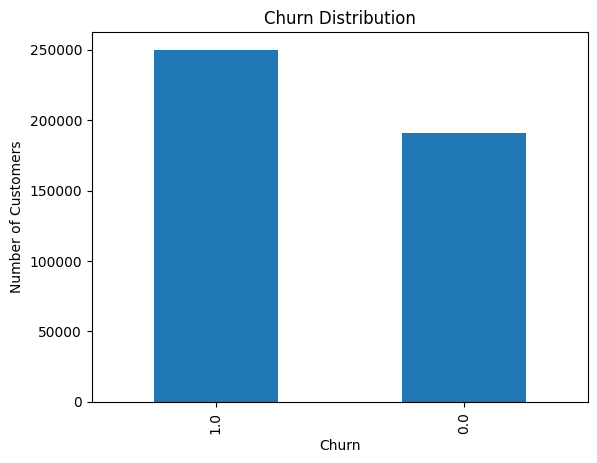

In [19]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

###
The dataset contains more churned customers than retained customers.

Approximately 56.7% of customers have churned while 43.3% have remained
with the company.

Although the classes are not perfectly balanced, the imbalance is
moderate and significantly less severe than in fraud detection datasets.

### Churn by Contract Length

In [17]:



# Create churn proportions by contract length
contract_churn_percent = (
    pd.crosstab(
        df["Contract Length"],
        df["Churn"],
        normalize="index"
    ) * 100
)

contract_churn_percent.round(2)

Churn,0.0,1.0
Contract Length,,
Annual,53.92,46.08
Monthly,0.00,100.00
Quarterly,53.97,46.03


###
ontract length appears to be a strong predictor of customer churn.

Customers on monthly contracts experienced a churn rate of 100%,
whereas customers on annual and quarterly contracts exhibited churn
rates of approximately 46%.

This suggests that longer contractual commitments are associated with
higher customer retention.

### Churn by Gender

In [20]:
gender_churn_percent =pd.crosstab(df["Gender"],df["Churn"],normalize = "index") *100 

gender_churn_percent.round(2)

Churn,0.0,1.0
Gender,,
Female,33.33,66.67
Male,50.87,49.13


###
Gender appears to be associated with customer churn in this dataset.

Female customers exhibit a churn rate of approximately 66.7%, whereas
male customers exhibit a churn rate of approximately 49.1%.

This suggests that female customers are more likely to leave the service
than male customers.

### Churn by Subscription Type

In [21]:
subscription_churn = pd.crosstab(
    df["Subscription Type"],
    df["Churn"],
    normalize="index"
) * 100

subscription_churn.round(2)

Churn,0.0,1.0
Subscription Type,,
Basic,41.82,58.18
Premium,44.06,55.94
Standard,43.93,56.07


### 
Subscription type does not appear to have a strong relationship with
customer churn in this dataset.

Customers across Basic, Premium and Standard subscriptions exhibit
similar churn rates, ranging from approximately 55.9% to 58.2%.

This suggests that subscription type may have relatively low predictive
power compared to variables such as contract length or gender.

### Churn by Support Calls

In [23]:
subscription_churn = (pd.crosstab( df["Support Calls"] ,df["Churn"] , normalize = "index") * 100 )
subscription_churn.round(2)

Churn,0.0,1.0
Support Calls,,
0.0,69.72,30.28
1.0,69.64,30.36
2.0,68.45,31.55
3.0,58.36,41.64
4.0,41.50,58.50
5.0,5.29,94.71
6.0,0.00,100.00
7.0,0.00,100.00
8.0,0.00,100.00


### 
Support calls appear to be a strong predictor of customer churn.

Customers with few support calls have relatively low churn rates, while
customers with five or more support calls exhibit extremely high churn
rates, reaching 100% for six or more support calls.

This suggests that customer dissatisfaction may be strongly associated
with churn.

### Churn by Payment Delay

In [25]:
PaymentDelay_churn = (pd.crosstab(df["Payment Delay"] , df["Churn"] , normalize = "index") * 100)
PaymentDelay_churn.round(2)

Churn,0.0,1.0
Payment Delay,,
0.0,53.33,46.67
1.0,54.22,45.78
2.0,53.32,46.68
3.0,53.42,46.58
4.0,53.64,46.36
5.0,53.38,46.62
6.0,53.31,46.69
7.0,53.67,46.33
8.0,52.88,47.12


### Churn by Tenure

In [26]:
Tenure_churn = (pd.crosstab(df["Tenure"] , df["Churn"] , normalize = "index") * 100)
Tenure_churn.round(2)

Churn,0.0,1.0
Tenure,,
1.0,34.63,65.37
2.0,35.29,64.71
3.0,36.56,63.44
4.0,35.86,64.14
5.0,35.49,64.51
6.0,46.47,53.53
7.0,45.42,54.58
8.0,44.67,55.33
9.0,46.20,53.80


### 
The cross-tabulation produces a very large table because Tenure
contains many unique values.

As a result, it is difficult to identify meaningful patterns in Tenure behaviour from this output alone.

For numerical variables with many unique values, comparing average values
across churn groups provides a more interpretable summary.

### Comparing averages values across churn groups

In [38]:
df.groupby("Churn")["Tenure"].mean()

Churn
0.0    32.281754
1.0    30.473598
Name: Tenure, dtype: float64

### 
Customers who remained with the company had a slightly longer average
tenure of approximately 32.3 months compared to 30.5 months for customers
who churned.

This suggests that customers with shorter relationships with the company
may be somewhat more likely to churn, although the difference is relatively
small, indicating that tenure is likely a weak predictor of customer churn.

### Churn by Usage Frequency

In [30]:
UsageFrequency_churn = (pd.crosstab(df["Usage Frequency"] , df["Churn"] , normalize = "index") * 100)
UsageFrequency_churn.round(2)

Churn,0.0,1.0
Usage Frequency,,
1.0,38.28,61.72
2.0,37.82,62.18
3.0,39.23,60.77
4.0,38.55,61.45
5.0,38.60,61.40
6.0,38.04,61.96
7.0,40.16,59.84
8.0,38.24,61.76
9.0,38.77,61.23


### 
Usage frequency appears to have a weak to moderate relationship with
customer churn.

Customers with very low usage frequencies exhibit slightly higher churn
rates than more active customers.

This suggests that customer engagement may influence churn behaviour,
although the effect is not particularly strong.

### Churn by Total Spend

In [35]:
df.groupby("Churn")["Total Spend"].mean()

Churn
0.0    749.953111
1.0    541.285528
Name: Total Spend, dtype: float64

### 
Customers who remained with the company had a higher average total spend
than customers who churned.

This suggests that higher customer spending is associated with lower
churn rates and improved customer retention.

### Churn by Last Interaction

In [33]:
LastInteraction_churn = (pd.crosstab(df["Last Interaction"] , df["Churn"] , normalize = "index") * 100)
LastInteraction_churn.round(2)

Churn,0.0,1.0
Last Interaction,,
1.0,51.19,48.81
2.0,50.54,49.46
3.0,50.45,49.55
4.0,50.95,49.05
5.0,50.86,49.14
6.0,50.80,49.20
7.0,50.60,49.40
8.0,51.01,48.99
9.0,50.52,49.48


###
Last interaction appears to be associated with customer churn.

Customers with recent interactions exhibit churn rates of approximately
49%, whereas customers with longer periods since their last interaction
exhibit churn rates of approximately 66%.

This suggests that reduced customer engagement may increase the
likelihood of churn.

### Correlation Analysis

In [39]:
corr = df.select_dtypes(
    include=["float64", "int64"]
).corr()

corr

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
CustomerID,1.000000,-0.181977,0.044129,0.038455,-0.482894,-0.262029,0.359289,-0.125356,-0.839365
Age,-0.181977,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,0.044129,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,0.038455,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,-0.482894,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,-0.262029,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,0.359289,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,-0.125356,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,-0.839365,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


### Correlation Heatmap

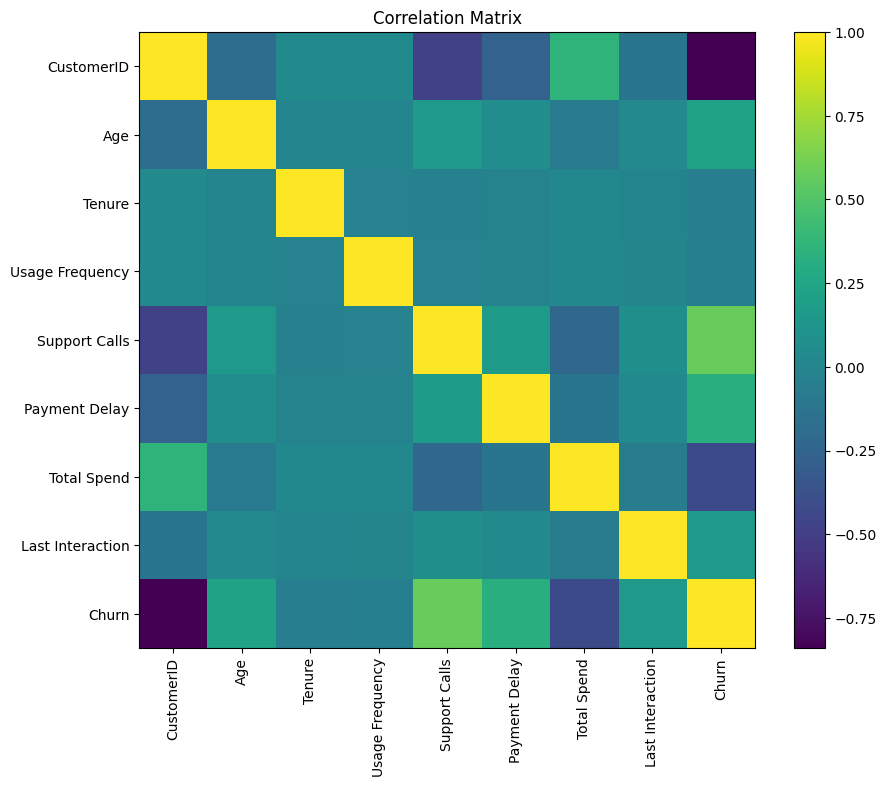

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")
plt.show()

### 
The correlation matrix provides a visual representation of relationships
between numerical variables.

Variables exhibiting stronger positive or negative correlations with
Churn may be more informative predictors in machine learning models.

Correlation analysis also helps identify relationships between predictor
variables that may influence model performance.